# Visualisations Interactives — Crowd Sound Project

Exploration interactive des sons de foule par réduction dimensionnelle (UMAP, t-SNE) et features acoustiques.

# 1. Importation des librairies

In [1]:
import os
import json
import numpy as np
import pandas as pd

import plotly.express as px

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

# 2. Chargement des données

In [2]:
outputs_folder = "../outputs"

data = []

for sound_folder in os.listdir(outputs_folder):

    json_path = os.path.join(outputs_folder, sound_folder, "results.json")

    if os.path.exists(json_path):

        with open(json_path, "r") as f:
            result = json.load(f)

            # label A / J
            result["group"] = sound_folder[0]

            data.append(result)

df = pd.DataFrame(data)

print("DATA LOADED")
print(df.shape)
df.head()

DATA LOADED
(52, 10)


,file,duration,global_intensity,f0_mean,f0_variability,spectral_centroid_mean,spectral_bandwidth_mean,spectral_rolloff_mean,mfcc_mean,group
0,A17.wav,1.500023,0.038223,153.082832,72.278269,2498.376197,2448.852118,4669.889198,"[-268.4269104003906, 186.66883850097656, -100....",A
1,A15.wav,1.500045,0.039969,177.602151,81.065714,2423.793932,2527.907365,4826.584660,"[-266.69189453125, 186.16000366210938, -87.469...",A
2,J8.wav,1.500000,0.043682,135.338844,86.412480,1683.752403,1508.542672,2755.918720,"[-292.8818359375, 242.25575256347656, -94.3273...",J
3,J18.wav,1.500000,0.042461,232.198165,139.605847,3018.489902,1639.247107,4305.518617,"[-400.82855224609375, 242.2602996826172, -53.2...",J
4,J3.wav,1.500000,0.040108,198.459007,166.081423,2365.620693,1758.312205,3767.151067,"[-253.87655639648438, 195.61439514160156, -129...",J


# 3. Préparation des features (MFCC, PCA, UMAP)

In [1]:
audio_dir = os.path.abspath("../data/sounds")
df["audio_path"] = df["file"].apply(lambda x: os.path.join(audio_dir, x))

NameError: name 'os' is not defined

In [4]:
X = np.array(df["mfcc_mean"].tolist())

print("Shape MFCC matrix:", X.shape)

Shape MFCC matrix: (52, 13)


In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

df["PC1"] = pca_result[:, 0]
df["PC2"] = pca_result[:, 1]

print("Explained variance:", pca.explained_variance_ratio_)

Explained variance: [0.26152166 0.19353049]


In [7]:
import umap

reducer = umap.UMAP(
    n_neighbors=10,
    min_dist=0.3,
    random_state=42
)

umap_result = reducer.fit_transform(X_scaled)

df["UMAP1"] = umap_result[:, 0]
df["UMAP2"] = umap_result[:, 1]

In [8]:
import ipywidgets as widgets
from IPython.display import display
import plotly.express as px
import IPython.display as ipd

In [9]:
group_selector = widgets.SelectMultiple(
    options=df["group"].unique(),
    value=tuple(df["group"].unique()),
    description="Group"
)

projection_selector = widgets.ToggleButtons(
    options=["PCA", "UMAP"],
    description="Projection"
)

display(group_selector, projection_selector)

SelectMultiple(description='Group', index=(0, 1), options=('A', 'J'), value=('A', 'J'))

ToggleButtons(description='Projection', options=('PCA', 'UMAP'), value='PCA')

In [10]:
def play_audio(path):
    return ipd.Audio(path, autoplay=True)

In [11]:
def update_plot(groups, projection):

    filtered_df = df[df["group"].isin(groups)].copy()

    if filtered_df.empty:
        print("Aucune donnée")
        return

    if projection == "PCA":
        x, y = "PC1", "PC2"
    else:
        x, y = "UMAP1", "UMAP2"

    fig = px.scatter(
        filtered_df,
        x=x,
        y=y,
        color="group",
        hover_name="file",
        title=f"{projection} of Crowd Sounds"
    )

    fig.show()

In [12]:
plot_out = widgets.interactive_output(
    update_plot,
    {
        "groups": group_selector,
        "projection": projection_selector
    }
)

display(plot_out)

Output()

In [13]:
import ipywidgets as widgets
from IPython.display import display

audio_out = widgets.Output()

display(audio_out)

Output()

In [27]:
file_selector = widgets.Dropdown(
    options=df["file"].tolist(),
    description="Sound"
)

display(file_selector)

Dropdown(description='Sound', options=('A17.wav', 'A15.wav', 'J8.wav', 'J18.wav', 'J3.wav', 'J11.wav', 'J5.wav…

In [28]:
button = widgets.Button(description="Play sound")

def on_click(b):
    path = df[df["file"] == file_selector.value]["audio_path"].values[0]

    with audio_out:
        audio_out.clear_output()
        display(play_audio(path))

button.on_click(on_click)

display(button)

Button(description='Play sound', style=ButtonStyle())

In [29]:
info_output = widgets.Output()

display(info_output)

Output()

In [30]:
def show_sound_info(change):

    if change["name"] == "value":

        selected_file = change["new"]

        row = df[df["file"] == selected_file].iloc[0]

        with info_output:

            info_output.clear_output()

            print(f"File: {row['file']}")
            print(f"Group: {row['group']}")
            print(f"Duration: {row['duration']:.2f} s")
            print(f"F0 mean: {row['f0_mean']:.2f}")
            print(f"Spectral centroid: {row['spectral_centroid_mean']:.2f}")

In [31]:
file_selector.observe(show_sound_info)

In [32]:
first_row = df[df["file"] == file_selector.value].iloc[0]

with info_output:

    print(f"File: {first_row['file']}")
    print(f"Group: {first_row['group']}")
    print(f"Duration: {first_row['duration']:.2f} s")
    print(f"F0 mean: {first_row['f0_mean']:.2f}")
    print(f"Spectral centroid: {first_row['spectral_centroid_mean']:.2f}")

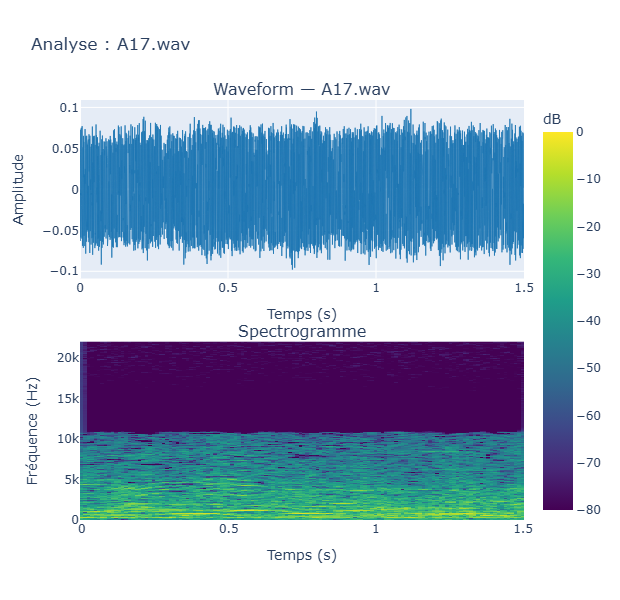

In [33]:
import librosa
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def show_sound_details(filename):
    path = df[df["file"] == filename]["audio_path"].values[0]
    y, sr = librosa.load(path, sr=None)
    
    # Waveform
    times = np.linspace(0, len(y)/sr, len(y))
    
    # Spectrogramme avec axes réels
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    freqs = librosa.fft_frequencies(sr=sr)
    frames = librosa.frames_to_time(np.arange(D.shape[1]), sr=sr)
    
    fig = make_subplots(rows=2, cols=1,
                        subplot_titles=(f"Waveform — {filename}", "Spectrogramme"),
                        vertical_spacing=0.15)
    
    fig.add_trace(go.Scatter(x=times, y=y, mode="lines",
                             line=dict(color="#1f77b4", width=0.8),
                             name="Amplitude"), row=1, col=1)
    
    fig.add_trace(go.Heatmap(z=D,
                             x=frames,
                             y=freqs,
                             colorscale="Viridis",
                             colorbar=dict(title="dB"),
                             name="Spectrogramme"), row=2, col=1)
    
    fig.update_layout(title=f"Analyse : {filename}", height=600, showlegend=False)
    fig.update_xaxes(title_text="Temps (s)", row=1, col=1)
    fig.update_xaxes(title_text="Temps (s)", row=2, col=1)
    fig.update_yaxes(title_text="Amplitude", row=1, col=1)
    fig.update_yaxes(title_text="Fréquence (Hz)", row=2, col=1)
    
    fig.show()

def on_file_change(change):
    if change["name"] == "value":
        show_sound_details(change["new"])

file_selector.unobserve_all()
file_selector.observe(on_file_change)
show_sound_details(file_selector.value)

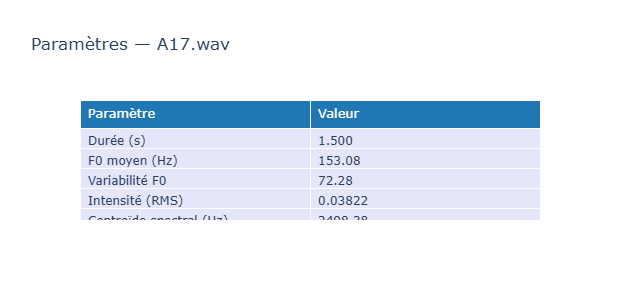

In [34]:
def show_sound_params(filename):
    row = df[df["file"] == filename].iloc[0]
    
    params = {
        "Paramètre": ["Durée (s)", "F0 moyen (Hz)", "Variabilité F0", 
                      "Intensité (RMS)", "Centroïde spectral (Hz)", 
                      "Largeur de bande (Hz)", "Rolloff spectral (Hz)"],
        "Valeur": [
            f"{row['duration']:.3f}",
            f"{row['f0_mean']:.2f}",
            f"{row['f0_variability']:.2f}",
            f"{row['global_intensity']:.5f}",
            f"{row['spectral_centroid_mean']:.2f}",
            f"{row['spectral_bandwidth_mean']:.2f}",
            f"{row['spectral_rolloff_mean']:.2f}"
        ]
    }
    
    fig = go.Figure(data=[go.Table(
        header=dict(values=["Paramètre", "Valeur"],
                    fill_color="#1f77b4",
                    font=dict(color="white", size=13),
                    align="left"),
        cells=dict(values=[params["Paramètre"], params["Valeur"]],
                   fill_color="lavender",
                   align="left",
                   font=dict(size=12))
    )])
    fig.update_layout(title=f"Paramètres — {filename}", height=300)
    fig.show()

def on_file_change(change):
    if change["name"] == "value":
        show_sound_details(change["new"])
        show_sound_params(change["new"])

file_selector.unobserve_all()
file_selector.observe(on_file_change)
show_sound_params(file_selector.value)

In [40]:
features = {
    "F0 moyen (Hz)": "f0_mean",
    "Variabilité F0": "f0_variability",
    "Intensité (RMS)": "global_intensity",
    "Centroïde spectral (Hz)": "spectral_centroid_mean",
    "Largeur de bande (Hz)": "spectral_bandwidth_mean",
    "Rolloff spectral (Hz)": "spectral_rolloff_mean",
    "Durée (s)": "duration"
}

feature_selector = widgets.Dropdown(
    options=list(features.keys()),
    description="Feature X",
    style={"description_width": "initial"}
)

feature_selector2 = widgets.Dropdown(
    options=list(features.keys()),
    value=list(features.keys())[1],
    description="Feature Y",
    style={"description_width": "initial"}
)

feature_audio_out = widgets.Output()
feature_fig_container = widgets.Output()

def update_feature_plot(fx, fy):
    with feature_fig_container:
        feature_fig_container.clear_output(wait=True)
        
        fig = go.FigureWidget()
        for grp, color in [("A", "#1f77b4"), ("J", "#ff7f0e")]:
            sub = df[df["group"] == grp]
            fig.add_trace(go.Scatter(
                x=sub[features[fx]],
                y=sub[features[fy]],
                mode="markers",
                name=f"Groupe {grp}",
                marker=dict(size=10, color=color, opacity=0.8),
                text=sub["file"].values,
                customdata=sub[["audio_path", "f0_mean", "f0_variability",
                                 "global_intensity", "spectral_centroid_mean",
                                 "spectral_bandwidth_mean", "duration"]].values,
                hovertemplate=(
                    "<b>%{text}</b><br>"
                    "F0: %{customdata[1]:.1f} Hz<br>"
                    "Variabilité F0: %{customdata[2]:.2f}<br>"
                    "Intensité: %{customdata[3]:.5f}<br>"
                    "Centroïde spectral: %{customdata[4]:.0f} Hz<br>"
                    "Largeur de bande: %{customdata[5]:.0f} Hz<br>"
                    "Durée: %{customdata[6]:.2f} s<br>"
                    "<i>Cliquer pour écouter</i>"
                    "<extra></extra>"
                )
            ))
        
        fig.update_layout(
            title=f"{fx} vs {fy} — Cliquer pour écouter",
            xaxis_title=fx,
            yaxis_title=fy
        )
        
        def on_click(trace, points, state):
            if points.point_inds:
                idx = points.point_inds[0]
                path = trace.customdata[idx][0]
                name = trace.text[idx]
                with feature_audio_out:
                    feature_audio_out.clear_output()
                    print(f"▶ {name}")
                    display(Audio(path, autoplay=True))
        
        for trace in fig.data:
            trace.on_click(on_click)
        
        display(fig)

plot_out2 = widgets.interactive_output(
    update_feature_plot,
    {"fx": feature_selector, "fy": feature_selector2}
)

display(feature_selector, feature_selector2, feature_fig_container, feature_audio_out)
update_feature_plot(feature_selector.value, feature_selector2.value)

Dropdown(description='Feature X', options=('F0 moyen (Hz)', 'Variabilité F0', 'Intensité (RMS)', 'Centroïde sp…

Dropdown(description='Feature Y', index=1, options=('F0 moyen (Hz)', 'Variabilité F0', 'Intensité (RMS)', 'Cen…

Output()

Output()